In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # For reproducibility
pd.set_option('display.max_columns', None)  # Show all columns in the output
sns.set(style="whitegrid")  # Set seaborn style for plots


In [4]:
df = pd.read_csv("titanic_dataset.csv")

In [5]:
df.shape

(891, 15)

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [49]:
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["sex", "embarked", "class", "who", "deck", "embark_town", "alive", "alone", "survived", "pclass"]
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'alone', 'survived', 'pclass']


### 3. Numerical Features Analysis

In [11]:
df[num_cols].head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


### Summary statistics

In [13]:
df[num_cols].describe()

,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [17]:
#### 4 Variance and Standard Deviation

print(df[num_cols].var())
print("-" * 40)
print(df[num_cols].std())

age       211.019125
fare     2469.436846
sibsp       1.216043
parch       0.649728
dtype: float64
----------------------------------------
age      14.526497
fare     49.693429
sibsp     1.102743
parch     0.806057
dtype: float64


In [19]:
print("\nSkewness")
print(df[num_cols].skew())  ### skewness measures the asymmetry of the distribution of values in a dataset. A skewness value greater than 0 indicates a right-skewed distribution, while a value less than 0 indicates a left-skewed distribution. A value close to 0 suggests a symmetric distribution.
print("\nKurtosis")
print(df[num_cols].kurtosis())  ### kurtosis measures the "tailedness


Skewness
age      0.389108
fare     4.787317
sibsp    3.695352
parch    2.749117
dtype: float64

Kurtosis
age       0.178274
fare     33.398141
sibsp    17.880420
parch     9.778125
dtype: float64


In [ ]:


def plot_boxplots(df, p):
    color = ["red", "blue", "green", "black"]
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        p
        # plt.title(f'Boxplot of {col}')
        # plt.xlabel(col)
        plt.show()



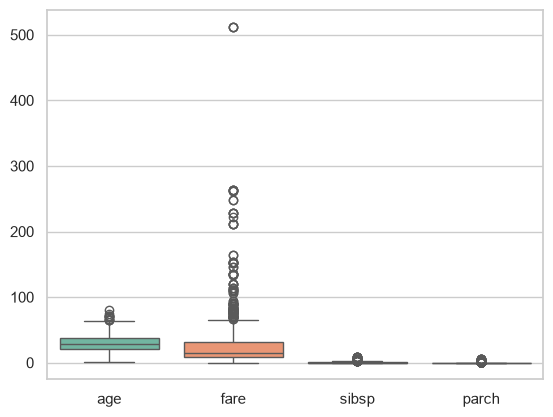

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [36]:
plot_boxplots(df, sns.boxplot(data=df[num_cols], palette="Set2"))

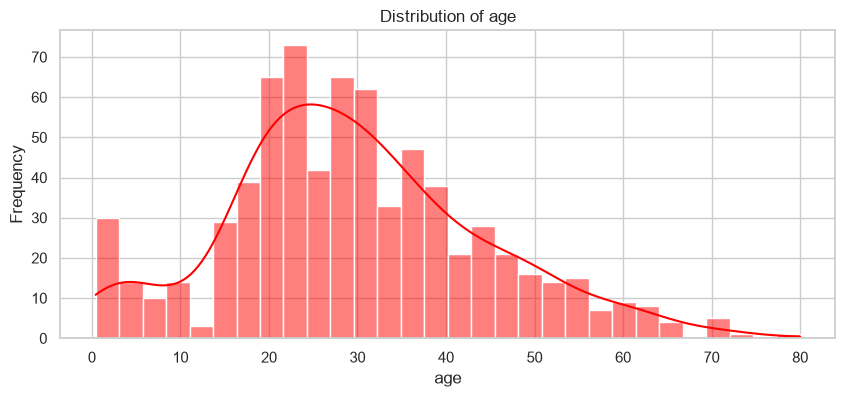

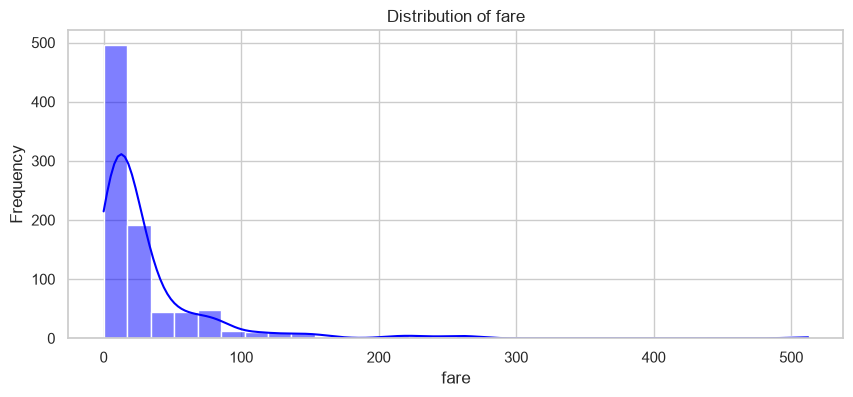

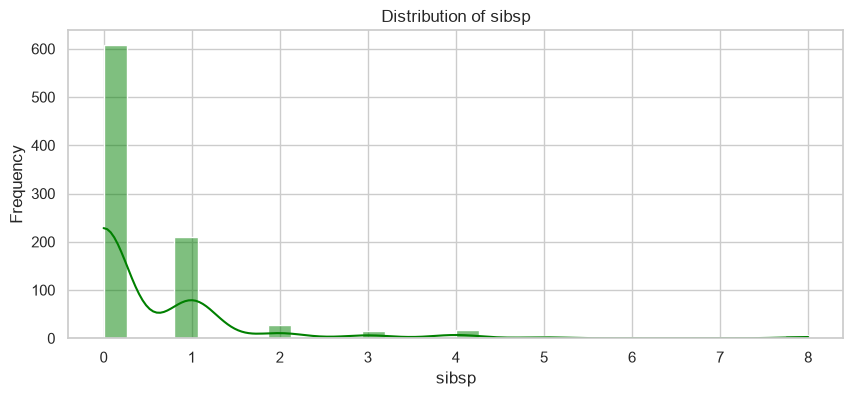

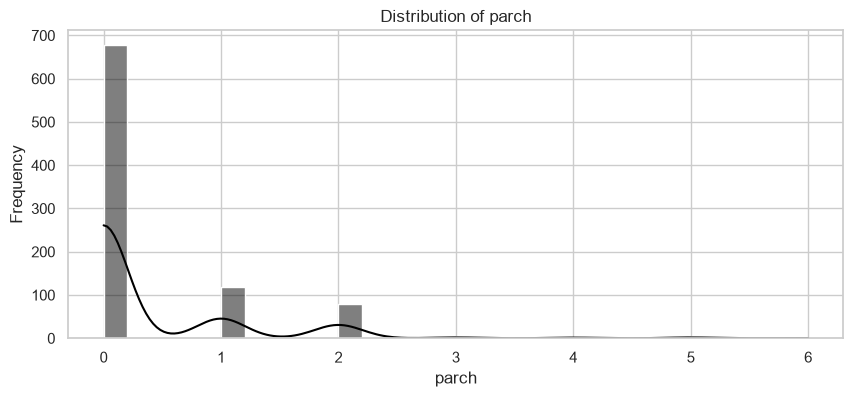

In [37]:
#### Boxplots for Numerical Features
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30, color=color[num_cols.index(col)])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

#### 4. Categorical Features - Analysis

In [39]:
df[cat_cols].head()

,sex,embarked,class,who,deck,embark_town,alive,alone
0,male,S,Third,man,NaN,Southampton,no,False
1,female,C,First,woman,C,Cherbourg,yes,False
2,female,S,Third,woman,NaN,Southampton,yes,True
3,female,S,First,woman,C,Southampton,yes,False
4,male,S,Third,man,NaN,Southampton,no,True


##### 5.1. Frequency Table

In [47]:
print(df["pclass"].value_counts())
print("----"*50)
print(df["pclass"].value_counts(normalize=True))  # Proportions)

pclass
3    491
1    216
2    184
Name: count, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [50]:
for col in cat_cols:
    print(f"\nFrequency Table for {col}:")
    print(df[col].value_counts())
    print(f"\nProportions for {col}:")
    print(df[col].value_counts(normalize=True))


Frequency Table for sex:
sex
male      577
female    314
Name: count, dtype: int64

Proportions for sex:
sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

Frequency Table for embarked:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Proportions for embarked:
embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

Frequency Table for class:
class
Third     491
First     216
Second    184
Name: count, dtype: int64

Proportions for class:
class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64

Frequency Table for who:
who
man      537
woman    271
child     83
Name: count, dtype: int64

Proportions for who:
who
man      0.602694
woman    0.304153
child    0.093154
Name: proportion, dtype: float64

Frequency Table for deck:
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

Proportions for deck:
deck
C    0.290640
B    0.231527
D    0.162562
E